# Challenge 5  — Deploy Agent (Bonous)

**Author:** Ayesha Shafquat  
**Date:** August 21, 2026

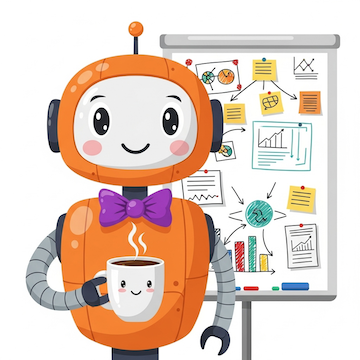

**Environment Setup — Cloud Authentication**

In [1]:
!bash <(curl -sSL https://storage.googleapis.com/cloud-samples-data/adc/setup_adc.sh)

   Google Cloud Model API & Gemini: ADC setup script
✅ gcloud CLI found at: /root/google-cloud-sdk/bin/gcloud

--- Project Setup ---
Enter your Google Cloud Project ID (NOT the name).
Project ID: qwiklabs-gcp-04-1eed0b5acc92

--- Authenticating ---
Authorizing Application Default Credentials (ADC)...

You are running on a Google Compute Engine virtual machine.
The service credentials associated with this virtual machine
will automatically be used by Application Default
Credentials, so it is not necessary to use this command.

If you decide to proceed anyway, your user credentials may be visible
to others with access to this virtual machine. Are you sure you want
to authenticate with your personal account?

Do you want to continue (Y/n)?  y

Go to the following link in your browser, and complete the sign-in prompts:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=https%3A%2F

**Environment Setup — Install Required Packages**

In [2]:
!pip install -q -U google-adk requests "google-cloud-aiplatform[agent_engines,adk]"

**Environment Setup - Configure Vertex AI**

In [4]:
import os
import google.auth

LOCATION = "us-central1"

try:
    _, project_id = google.auth.default()
except google.auth.exceptions.DefaultCredentialsError:
    project_id = None

if not project_id:
    project_id = input("Could not auto-detect a GCP project. Enter your project ID: ").strip()

os.environ["GOOGLE_GENAI_USE_VERTEXAI"] = "TRUE"
os.environ["GOOGLE_CLOUD_PROJECT"] = project_id
os.environ["GOOGLE_CLOUD_LOCATION"] = LOCATION

print(f"Using Vertex AI project '{project_id}' in '{LOCATION}'.")

Using Vertex AI project 'qwiklabs-gcp-04-1eed0b5acc92' in 'us-central1'.


**Import ADK**

In [5]:
from google.adk.agents import Agent, SequentialAgent
from google.adk.tools import google_search
import vertexai
from vertexai.preview import reasoning_engines

vertexai.init(
    project=project_id,
    location=LOCATION,
)

MODEL = "gemini-2.5-flash"

print("ADK workflow components imported.")

ADK workflow components imported.


**Search Agent**

In [6]:
SEARCH_AGENT_INSTRUCTIONS = """
You are the research/search agent.

Answer the user's question using Google Search.

Requirements:
- Find accurate and current information.
- Include the important facts needed to answer the question.
- Mention source names or links when available.
- Do not critique or refine the answer yet.

Return a clear initial answer for the critique agent to review.
"""

search_agent = Agent(
    name="search_agent",
    model=MODEL,
    description="Finds current information needed to answer the user's question.",
    instruction=SEARCH_AGENT_INSTRUCTIONS,
    tools=[google_search],
    output_key="search_result",
)

print("Search agent created.")


Search agent created.


**Critique Agent**

In [7]:
CRITIQUE_AGENT_INSTRUCTIONS = """
You are the critique agent.

Review the initial answer below:

{search_result}

Check the answer for:
- whether it actually answers the user's question,
- unsupported or unclear claims,
- missing important information,
- accuracy and consistency,
- clarity and organization,
- whether the available sources support the answer.

Do not write the final answer.

Return a short list of specific improvements for the refine agent.
"""

critique_agent = Agent(
    name="critique_agent",
    model=MODEL,
    description="Reviews the initial answer and recommends improvements.",
    instruction=CRITIQUE_AGENT_INSTRUCTIONS,
    output_key="critique_result",
)

print("Critique agent created.")


Critique agent created.


**Refine Agent**

In [8]:
REFINE_AGENT_INSTRUCTIONS = """
You are the refine agent.

Original answer:

{search_result}

Critique and suggested improvements:

{critique_result}

Rewrite the answer so that it is:
- accurate,
- complete,
- clear,
- concise,
- responsive to the user's original question.

Apply the critique where appropriate.
Keep useful source information from the original answer.

Return only the improved final answer.
Do not mention the internal workflow, critique agent, or refinement process.
"""

refine_agent = Agent(
    name="refine_agent",
    model=MODEL,
    description="Produces the final improved answer using the critique.",
    instruction=REFINE_AGENT_INSTRUCTIONS,
    output_key="refined_result",
)

print("Refine agent created.")


Refine agent created.


**Sequential Team**

Search -> Critique -> Refine

In [9]:
answer_team = SequentialAgent(
    name="answer_team",
    description=(
        "Answers a question by searching for information, "
        "critiquing the initial answer, and refining the final response."
    ),
    sub_agents=[
        search_agent,
        critique_agent,
        refine_agent,
    ],
)

print("Sequential answer team created.")


Sequential answer team created.


/tmp/ipykernel_10273/3753890973.py:1: DeprecationWarning: SequentialAgent is deprecated in favor of Workflow and will be removed in a future version. Workflow cannot yet be used as an LlmAgent sub-agent.
  answer_team = SequentialAgent(


**Root Agent**

In [10]:
GREETER_INSTRUCTIONS = """
You are the greeter and coordinator.

When the user asks a question:
1. Send the request to the answer_team workflow.
2. Allow the Search, Critique, and Refine agents to run in order.
3. Return the refined final answer to the user.

Do not skip the workflow and do not answer the research question yourself.
"""

greeter_agent = Agent(
    name="greeter_agent",
    model=MODEL,
    description="Greets the user and sends questions through the verified answer workflow.",
    instruction=GREETER_INSTRUCTIONS,
    sub_agents=[
        answer_team,
    ],
)

print("Greeter/root agent created.")


Greeter/root agent created.


**ADK**

In [11]:
app = reasoning_engines.AdkApp(
    agent=greeter_agent,
)

print("Challenge 4 workflow app is ready.")

Challenge 4 workflow app is ready.


**Helper**

In [12]:
def run_workflow_test(message: str) -> None:
    """Run the workflow and print events from each agent."""
    user_id = "challenge4-user"

    session = app.create_session(
        user_id=user_id,
    )

    print(f"USER: {message}\n")

    for event in app.stream_query(
        user_id=user_id,
        session_id=session["id"],
        message=message,
    ):
        author = event.get("author", "unknown")
        print(f"EVENT FROM: {author}")
        content = event.get("content", {})

        for part in content.get("parts", []):
            if "text" in part and part["text"]:
                text = part["text"].strip()
                print(f"  TEXT: {text[:800]}")

        print()


**Test**

**Staging Bucket**

In [13]:
STAGING_BUCKET = f"gs://{project_id}-challenge5-agent-staging"

!gcloud storage buckets create $STAGING_BUCKET \
    --location=US

Creating gs://qwiklabs-gcp-04-1eed0b5acc92-challenge5-agent-staging/...
ERROR: (gcloud.storage.buckets.create) HTTPError 409: Your previous request to create the named bucket succeeded and you already own it.


**Initialize Vertex AI**

In [14]:
from vertexai import agent_engines
import os

DEPLOYMENT_LOCATION = "us"

os.environ["GOOGLE_CLOUD_LOCATION"] = DEPLOYMENT_LOCATION

vertexai.init(
    project=project_id,
    location=DEPLOYMENT_LOCATION,
    staging_bucket=STAGING_BUCKET,
)

print("Project:", project_id)
print("Agent deployment location:", DEPLOYMENT_LOCATION)
print("Staging bucket:", STAGING_BUCKET)
print("Vertex AI initialized for Agent Engine deployment.")


Project: qwiklabs-gcp-04-1eed0b5acc92
Agent deployment location: us
Staging bucket: gs://qwiklabs-gcp-04-1eed0b5acc92-challenge5-agent-staging
Vertex AI initialized for Agent Engine deployment.


In [15]:
deployment_app = agent_engines.AdkApp(
    agent=greeter_agent
)
print('Challenge 4 workflow packaged as an ADK app.')

Challenge 4 workflow packaged as an ADK app.


**Deploy**

In [16]:
DEPLOYMENT_REQUIREMENTS = [
    "google-cloud-aiplatform[agent_engines,adk]",
    "google-adk",
]

remote_agent = agent_engines.create(
    deployment_app,
    display_name="challenge-5-verified-answer-workflow",
    requirements=DEPLOYMENT_REQUIREMENTS,
)

print("Deployment complete.")
print("Resource name:", remote_agent.resource_name)
print(remote_agent.resource_name)

INFO:vertexai.agent_engines:Identified the following requirements: {'pydantic': '2.13.4', 'cloudpickle': '3.1.2', 'google-cloud-aiplatform': '1.165.1'}
INFO:vertexai.agent_engines:The following requirements are appended: {'cloudpickle==3.1.2', 'pydantic==2.13.4'}
INFO:vertexai.agent_engines:The final list of requirements: ['google-cloud-aiplatform[agent_engines,adk]', 'google-adk', 'cloudpickle==3.1.2', 'pydantic==2.13.4']
INFO:vertexai.agent_engines:Using bucket qwiklabs-gcp-04-1eed0b5acc92-challenge5-agent-staging
INFO:vertexai.agent_engines:Wrote to gs://qwiklabs-gcp-04-1eed0b5acc92-challenge5-agent-staging/agent_engine/agent_engine.pkl
INFO:vertexai.agent_engines:Writing to gs://qwiklabs-gcp-04-1eed0b5acc92-challenge5-agent-staging/agent_engine/requirements.txt
INFO:vertexai.agent_engines:Creating in-memory tarfile of extra_packages
INFO:vertexai.agent_engines:Writing to gs://qwiklabs-gcp-04-1eed0b5acc92-challenge5-agent-staging/agent_engine/dependencies.tar.gz
INFO:vertexai.agent_

Deployment complete.
Resource name: projects/894323792741/locations/us/reasoningEngines/4249568460889128960
projects/894323792741/locations/us/reasoningEngines/4249568460889128960
